In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv3.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 5
N_TICKS = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]
W = pd.read_csv('weights(inv_covariance_matrix_from_real_data).csv').to_numpy()

In [13]:
# метрика лосса: матрица ковариаций
# + байесовское обучение оптуной, все диапазоны были выбраны обще (далее будут сужаться)
def loss_msm(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret", "autocorr_on_ret_1", "autocorr_on_ret_5", "autocorr_on_ret_10", "autocorr_on_abs_1", "autocorr_on_abs_5", "autocorr_on_abs_10"]
    errors = np.zeros((len(num), 1))
    id = -1
    for i in num:
        id += 1
        errors[id] = t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]
    ans = errors.T @ W @ errors
    # print(ans.shape)
    return float(ans[0][0])

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 20, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 3, 50),
        'Chartist': trial.suggest_int('Chartist', 30, 120),
        'Universalist': trial.suggest_int('Universalist', 5, 50),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 0.05, 100, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 0.005, 10, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -4, -1),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 100, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 100, log=True),
        'Exchange_Volume': trial.suggest_int('Exchange_Volume', 1000, 20000)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(volume=params['Exchange_Volume'], std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'])
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, params['Exchange_Volume']) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, params['Exchange_Volume']) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, params['Exchange_Volume']) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, params['Exchange_Volume']) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, params['Exchange_Volume']) for _ in range(0)],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_msm(target_params, model_params))
        except Exception as e:
            print(e)
            continue

    if len(errors) != N_RUNS:
        return 1000
    return float(np.mean(errors))

In [14]:
# само обучение
study = optuna.create_study(study_name="calibration_msm(diff vol)4", direction="minimize", storage="sqlite:///calibration_msm(diff vol)4",  load_if_exists=True)
study.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-04-26 00:31:10,634] A new study created in RDB with name: calibration_msm(diff vol)4
Best trial: 0. Best value: 10745:   0%|          | 1/500 [00:40<5:32:48, 40.02s/it]

[I 2026-04-26 00:31:50,646] Trial 0 finished with value: 10745.038936820294 and parameters: {'Random': 91, 'Fundamentalist': 46, 'Chartist': 103, 'Universalist': 27, 'Transaction_cost': 0.00013218334995048923, 'Std': 0.9257788945198859, 'Std_Random': 0.3299778551460208, 'Avg_Traders': -3.1873476945115673, 'Last_Step': 0.4843745276986148, 'Last_Ret': 22.51761347138161, 'Noisy_Level': 0.03174278789041462, 'Exchange_Volume': 18466}. Best is trial 0 with value: 10745.038936820294.


Best trial: 1. Best value: 1333.81:   0%|          | 2/500 [01:15<5:10:09, 37.37s/it]

[I 2026-04-26 00:32:26,160] Trial 1 finished with value: 1333.8117745643103 and parameters: {'Random': 97, 'Fundamentalist': 6, 'Chartist': 118, 'Universalist': 35, 'Transaction_cost': 0.002047990036836441, 'Std': 96.00069951197825, 'Std_Random': 0.41980919518769005, 'Avg_Traders': -1.3445505396576505, 'Last_Step': 0.3463236652961068, 'Last_Ret': 1.4470535877808102, 'Noisy_Level': 13.224330311981989, 'Exchange_Volume': 16773}. Best is trial 1 with value: 1333.8117745643103.


Best trial: 1. Best value: 1333.81:   1%|          | 3/500 [01:26<3:30:50, 25.45s/it]

...

[I 2026-04-26 02:55:53,115] Trial 497 finished with value: 52.63778876942342 and parameters: {'Random': 98, 'Fundamentalist': 4, 'Chartist': 114, 'Universalist': 6, 'Transaction_cost': 0.0005248347421254525, 'Std': 2.2147337423280433, 'Std_Random': 0.06332049573679065, 'Avg_Traders': -2.9532396078147944, 'Last_Step': 0.8685897189354472, 'Last_Ret': 0.3624206399046985, 'Noisy_Level': 19.808440461566985, 'Exchange_Volume': 2146}. Best is trial 310 with value: 13.466522056442955.


Best trial: 310. Best value: 13.4665: 100%|█████████▉| 499/500 [2:24:53<00:12, 12.72s/it]

[I 2026-04-26 02:56:03,973] Trial 498 finished with value: 24.58605394225911 and parameters: {'Random': 98, 'Fundamentalist': 3, 'Chartist': 102, 'Universalist': 9, 'Transaction_cost': 0.0006040598997545463, 'Std': 3.403933103505855, 'Std_Random': 0.03389124173987969, 'Avg_Traders': -3.4400248678882988, 'Last_Step': 0.9198810294693957, 'Last_Ret': 0.7321934132941643, 'Noisy_Level': 0.021664145653885965, 'Exchange_Volume': 1434}. Best is trial 310 with value: 13.466522056442955.


Best trial: 310. Best value: 13.4665: 100%|██████████| 500/500 [2:25:04<00:00, 17.41s/it]

[I 2026-04-26 02:56:14,852] Trial 499 finished with value: 16.768652900308716 and parameters: {'Random': 96, 'Fundamentalist': 3, 'Chartist': 112, 'Universalist': 5, 'Transaction_cost': 0.0004560942159027706, 'Std': 4.313215454522425, 'Std_Random': 0.05338559573523785, 'Avg_Traders': -3.1404700014359475, 'Last_Step': 0.8887865121780615, 'Last_Ret': 0.4331406829007277, 'Noisy_Level': 0.005571271105403397, 'Exchange_Volume': 1743}. Best is trial 310 with value: 13.466522056442955.
Best params: {'Random': 94, 'Fundamentalist': 3, 'Chartist': 113, 'Universalist': 7, 'Transaction_cost': 0.00016861713484998662, 'Std': 0.340762698417331, 'Std_Random': 0.06921832448069358, 'Avg_Traders': -3.3299281531506537, 'Last_Step': 0.23739040536465286, 'Last_Ret': 0.11209270487875453, 'Noisy_Level': 0.017161636597668888, 'Exchange_Volume': 1026}
Best Score: 13.466522056442955


[I 2026-04-26 11:56:36,124] Using an existing study with name 'calibration_msm(diff vol)4' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_18868\3329723969.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


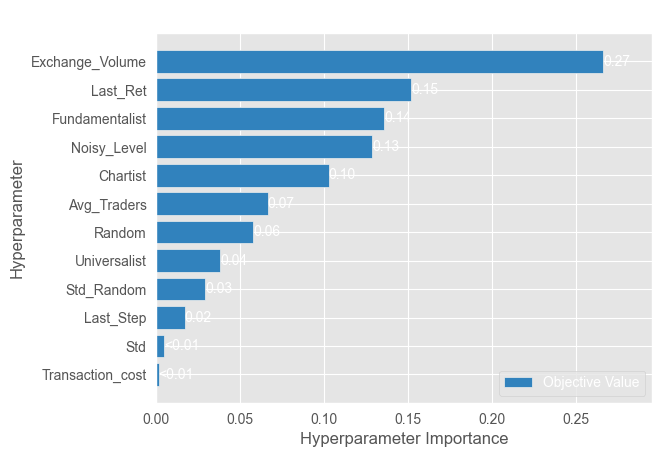

In [16]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study = optuna.create_study(study_name="calibration_msm(diff vol)4", direction="minimize", storage="sqlite:///calibration_msm(diff vol)4",  load_if_exists=True)
plot_param_importances(study)
plt.show()

C:\Users\rodion\AppData\Local\Temp\ipykernel_18868\2019636087.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study)


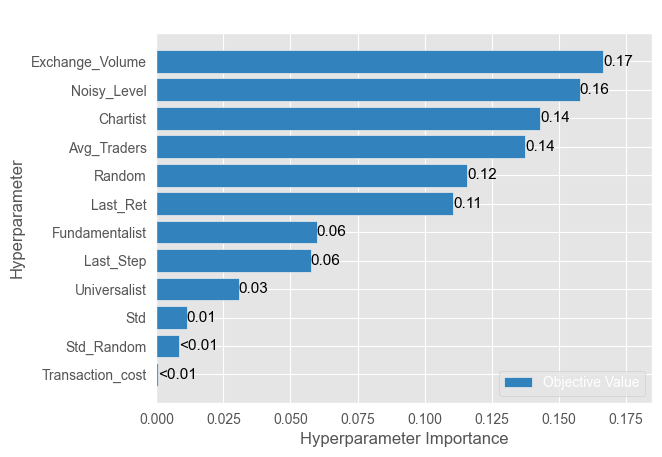

In [19]:
ax = plot_param_importances(study)
for txt in ax.texts:
    txt.set_color("black")   # можно "yellow", "red", "#ffffff" и т.д.
    txt.set_fontsize(11)

plt.show()